<a href="https://colab.research.google.com/github/Prathama-1/Prosperity-4---Solo42/blob/main/Round5_manual_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

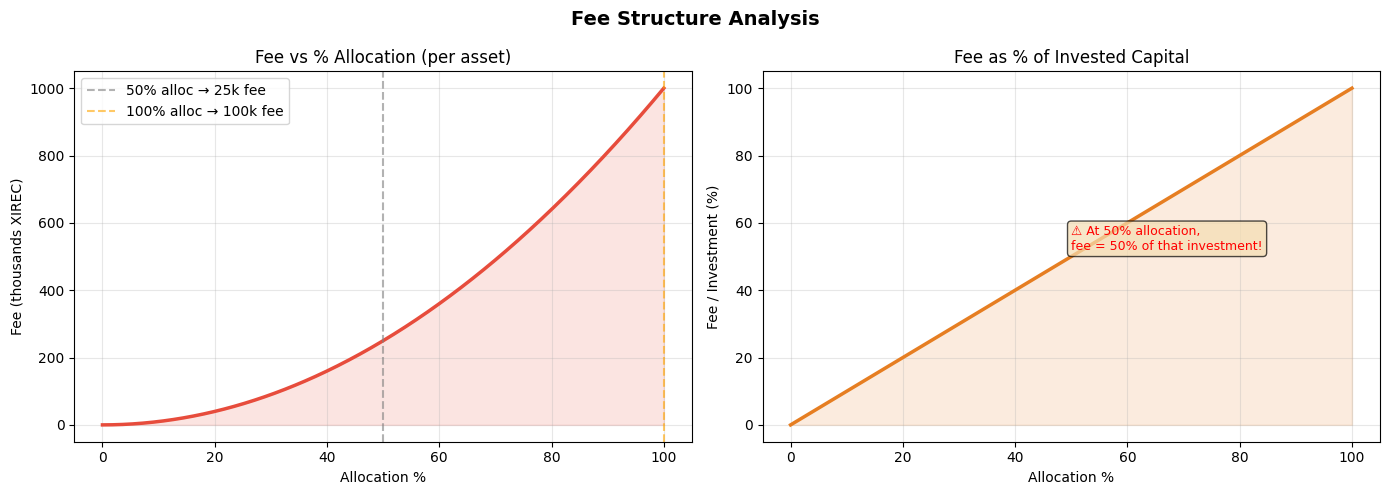

KEY INSIGHT: fee/investment = allocation% itself
→ If you put 10% in one asset, fee = 10% of that allocation = 1% of total budget
→ If you put 50% in one asset, fee = 50% of that allocation = 25% of total budget!

Fee table:
    5% alloc → fee =      2,500 XIREC  (5.0% of that position's capital)
   10% alloc → fee =     10,000 XIREC  (10.0% of that position's capital)
   15% alloc → fee =     22,500 XIREC  (15.0% of that position's capital)
   20% alloc → fee =     40,000 XIREC  (20.0% of that position's capital)
   25% alloc → fee =     62,500 XIREC  (25.0% of that position's capital)
   30% alloc → fee =     90,000 XIREC  (30.0% of that position's capital)
   40% alloc → fee =    160,000 XIREC  (40.0% of that position's capital)
   50% alloc → fee =    250,000 XIREC  (50.0% of that position's capital)
  100% alloc → fee =  1,000,000 XIREC  (100.0% of that position's capital)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import minimize, differential_evolution
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# CONSTANTS
# ─────────────────────────────────────────────
BUDGET = 1_000_000

def fee(pct: float, budget: float = BUDGET) -> float:
    """Fee for a single asset given % allocation (0-100)."""
    return (pct / 100) ** 2 * budget

def total_fee(pcts: list, budget: float = BUDGET) -> float:
    """Total fee across all assets."""
    return sum(fee(p, budget) for p in pcts)

# ─── Visualize fee structure ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fee Structure Analysis', fontsize=14, fontweight='bold')

v = np.linspace(0, 100, 500)
fees = (v / 100) ** 2 * BUDGET
marginal = 2 * v / 10000 * BUDGET  # d(fee)/dv

axes[0].plot(v, fees / 1000, color='#e74c3c', linewidth=2.5)
axes[0].set_title('Fee vs % Allocation (per asset)')
axes[0].set_xlabel('Allocation %')
axes[0].set_ylabel('Fee (thousands XIREC)')
axes[0].fill_between(v, fees / 1000, alpha=0.15, color='#e74c3c')
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.6, label='50% alloc → 25k fee')
axes[0].axvline(100, color='orange', linestyle='--', alpha=0.6, label='100% alloc → 100k fee')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Fee as % of invested capital = (v/100)^2 * budget / (v/100 * budget) = v/100
fee_pct_of_invested = v / 100 * 100  # this equals v %
axes[1].plot(v, fee_pct_of_invested, color='#e67e22', linewidth=2.5)
axes[1].set_title('Fee as % of Invested Capital')
axes[1].set_xlabel('Allocation %')
axes[1].set_ylabel('Fee / Investment (%)')
axes[1].fill_between(v, fee_pct_of_invested, alpha=0.15, color='#e67e22')
axes[1].grid(alpha=0.3)
axes[1].text(50, 52, '⚠ At 50% allocation,\nfee = 50% of that investment!',
             fontsize=9, color='red', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig('fee_structure.png', dpi=150, bbox_inches='tight')
plt.show()

print("KEY INSIGHT: fee/investment = allocation% itself")
print("→ If you put 10% in one asset, fee = 10% of that allocation = 1% of total budget")
print("→ If you put 50% in one asset, fee = 50% of that allocation = 25% of total budget!")
print("\nFee table:")
for pct in [5, 10, 15, 20, 25, 30, 40, 50, 100]:
    f = fee(pct)
    invested = pct / 100 * BUDGET
    print(f"  {pct:3d}% alloc → fee = {f:>10,.0f} XIREC  ({f/invested*100:.1f}% of that position's capital)")

In [4]:
# ════════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS & SETUP
# ════════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import minimize, differential_evolution
from scipy.stats import truncnorm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#16213e',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'axes.titlecolor': 'white',
    'grid.color': '#333',
    'grid.alpha': 0.4,
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#444',
})

BUDGET = 1_000_000

def fee(pct: float) -> float:
    """Exact fee for a single asset. pct in [0, 100]."""
    return (pct / 100) ** 2 * BUDGET

def net_pnl_single(pct: float, ret: float) -> float:
    """Net PnL for one asset. pct unsigned [0,100], ret signed (+ = price goes up)."""
    gross = (pct / 100) * BUDGET * ret
    return gross - fee(pct)

def portfolio_net_pnl(pcts: np.ndarray, rets: np.ndarray) -> float:
    """
    pcts: array of signed allocations [-100, 100] per asset
          positive = buy, negative = sell
    rets: array of realized returns (signed, from market)
          e.g. +0.30 means price rose 30%
    PnL = sum over assets of: (pct/100)*budget*ret - (|pct|/100)^2*budget
    """
    gross = np.sum((pcts / 100) * BUDGET * rets)
    fees  = np.sum((np.abs(pcts) / 100) ** 2 * BUDGET)
    return gross - fees

print('Setup complete. BUDGET =', f'{BUDGET:,}')
print()
print('Fee verification:')
for v in [10, 20, 30, 50, 100]:
    print(f'  {v}% alloc → fee = {fee(v):>10,.0f}  ({fee(v)/BUDGET*100:.1f}% of budget)')

Setup complete. BUDGET = 1,000,000

Fee verification:
  10% alloc → fee =     10,000  (1.0% of budget)
  20% alloc → fee =     40,000  (4.0% of budget)
  30% alloc → fee =     90,000  (9.0% of budget)
  50% alloc → fee =    250,000  (25.0% of budget)
  100% alloc → fee =  1,000,000  (100.0% of budget)


In [5]:
# ════════════════════════════════════════════════════════════════
# CELL 2 — ✏️  PARAMETER ZONE (EDIT THIS CELL)
# Define your return range estimates per asset based on news.
# direction: +1 = you want to BUY, -1 = you want to SELL
# ret_low / ret_high: range of plausible absolute returns
# ret_base: your best single estimate
# confidence: 0-1, how sure are you the direction is correct
#
# NOTE: ret values are MAGNITUDES (positive numbers).
# The direction field handles buy/sell.
# ════════════════════════════════════════════════════════════════

ASSETS = {
    #  name                  dir   ret_low  ret_base  ret_high  confidence
    'Thermalite Core':    {'dir':+1, 'low':0.10, 'base':0.30, 'high':0.50, 'conf':0.85},
    'Magma Ink':          {'dir':+1, 'low':0.10, 'base':0.25, 'high':0.40, 'conf':0.80},
    'Sulfur Reactor':     {'dir':+1, 'low':0.08, 'base':0.25, 'high':0.40, 'conf':0.88},
    'Scoria Paste':       {'dir':+1, 'low':0.02, 'base':0.12, 'high':0.25, 'conf':0.60},
    'Volcanic Incense':   {'dir':+1, 'low':0.01, 'base':0.08, 'high':0.20, 'conf':0.50},
    'Ashes of Phoenix':   {'dir':-1, 'low':0.01, 'base':0.05, 'high':0.15, 'conf':0.50},
    'Pyroflex Cells':     {'dir':-1, 'low':0.05, 'base':0.18, 'high':0.30, 'conf':0.75},
    'Obsidian Cutlery':   {'dir':-1, 'low':0.10, 'base':0.28, 'high':0.45, 'conf':0.85},
    'Lava Cake':          {'dir':-1, 'low':0.10, 'base':0.30, 'high':0.50, 'conf':0.88},
}

NAMES = list(ASSETS.keys())
N = len(NAMES)

# Derived arrays
DIRS   = np.array([ASSETS[n]['dir']  for n in NAMES], dtype=float)
LOWS   = np.array([ASSETS[n]['low']  for n in NAMES], dtype=float)
BASES  = np.array([ASSETS[n]['base'] for n in NAMES], dtype=float)
HIGHS  = np.array([ASSETS[n]['high'] for n in NAMES], dtype=float)
CONFS  = np.array([ASSETS[n]['conf'] for n in NAMES], dtype=float)

# Risk-adjusted base returns (for use in optimization)
RADJ_BASES = BASES * CONFS  # expected return weighted by confidence

# Display
df_params = pd.DataFrame({
    'Direction':   ['BUY' if d>0 else 'SELL' for d in DIRS],
    'Return Low':  [f'{v:.0%}' for v in LOWS],
    'Return Base': [f'{v:.0%}' for v in BASES],
    'Return High': [f'{v:.0%}' for v in HIGHS],
    'Confidence':  [f'{v:.0%}' for v in CONFS],
    'Risk-Adj Base': [f'{v:.0%}' for v in RADJ_BASES],
}, index=NAMES)
print(df_params.to_string())

                 Direction Return Low Return Base Return High Confidence Risk-Adj Base
Thermalite Core        BUY        10%         30%         50%        85%           26%
Magma Ink              BUY        10%         25%         40%        80%           20%
Sulfur Reactor         BUY         8%         25%         40%        88%           22%
Scoria Paste           BUY         2%         12%         25%        60%            7%
Volcanic Incense       BUY         1%          8%         20%        50%            4%
Ashes of Phoenix      SELL         1%          5%         15%        50%            2%
Pyroflex Cells        SELL         5%         18%         30%        75%           14%
Obsidian Cutlery      SELL        10%         28%         45%        85%           24%
Lava Cake             SELL        10%         30%         50%        88%           26%


═════════════════════════════════════════════════════════════════
CLOSED-FORM OPTIMAL ALLOCATION: v* = r × 50
MAX PnL per asset:              PnL* = budget × r² / 4
Break-even condition:           r > v / 100  (return > alloc%)
═════════════════════════════════════════════════════════════════



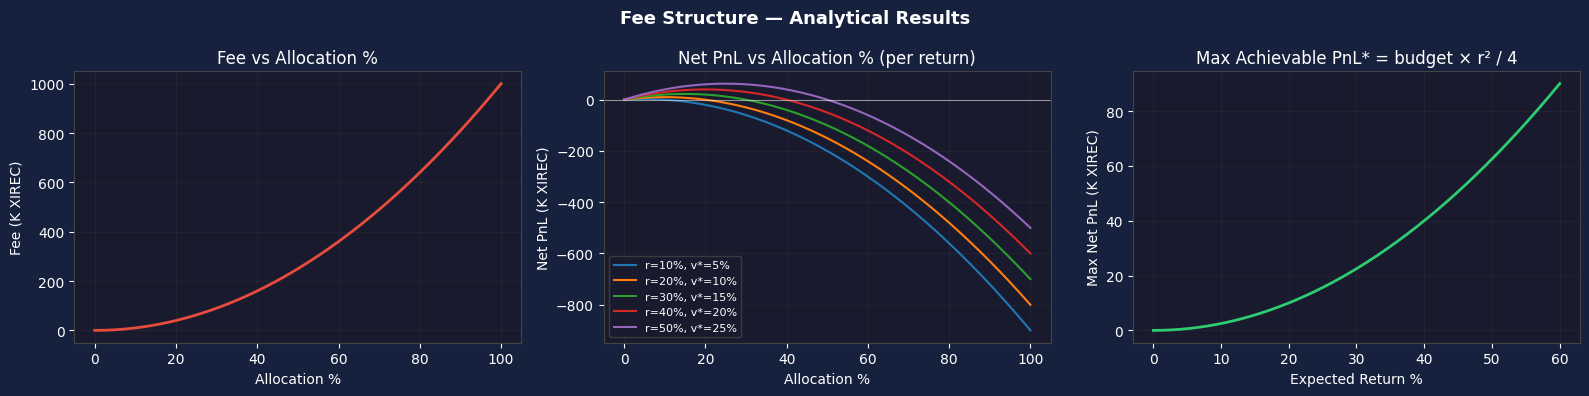


Asset                    r_base       v*     Max PnL*   Break-even r
--------------------------------------------------------------------
✅ Thermalite Core          25.5%    12.8%       16,256         12.8%
✅ Magma Ink                20.0%    10.0%       10,000         10.0%
✅ Sulfur Reactor           22.0%    11.0%       12,100         11.0%
✅ Scoria Paste              7.2%     3.6%        1,296          3.6%
✅ Volcanic Incense          4.0%     2.0%          400          2.0%
✅ Ashes of Phoenix          2.5%     1.2%          156          1.2%
✅ Pyroflex Cells           13.5%     6.8%        4,556          6.8%
✅ Obsidian Cutlery         23.8%    11.9%       14,161         11.9%
✅ Lava Cake                26.4%    13.2%       17,424         13.2%


In [6]:
# ════════════════════════════════════════════════════════════════
# CELL 3 — FEE MATH: ANALYTICAL DERIVATION
# Closed-form optimal allocation per asset (unconstrained)
# ════════════════════════════════════════════════════════════════

# For asset i:
#   PnL_i = (v_i/100)*budget*r_i - (v_i/100)^2*budget
#   d(PnL_i)/d(v_i) = budget/100 * r_i - 2*budget*v_i/10000 = 0
#   => v_i* = r_i * 50
#
# At v_i*:
#   Max PnL_i = (r_i*50/100)*budget*r_i - (r_i*50/100)^2*budget
#             = budget * r_i^2/2 - budget * r_i^2/4
#             = budget * r_i^2 / 4
#
# Break-even: PnL_i = 0  =>  r_i = v_i/100
#   i.e. your return must exceed your allocation percentage

print('═'*65)
print('CLOSED-FORM OPTIMAL ALLOCATION: v* = r × 50')
print('MAX PnL per asset:              PnL* = budget × r² / 4')
print('Break-even condition:           r > v / 100  (return > alloc%)')
print('═'*65)
print()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

v_range = np.linspace(0, 100, 500)
r_range = np.linspace(0, 0.6, 500)

# Plot 1: Fee curve
axes[0].plot(v_range, (v_range/100)**2 * BUDGET / 1000, color='#e74c3c', lw=2)
axes[0].set_title('Fee vs Allocation %')
axes[0].set_xlabel('Allocation %')
axes[0].set_ylabel('Fee (K XIREC)')
axes[0].grid(True)

# Plot 2: Net PnL curves for different return assumptions
for r_val in [0.10, 0.20, 0.30, 0.40, 0.50]:
    net = (v_range/100)*BUDGET*r_val - (v_range/100)**2*BUDGET
    v_opt = r_val * 50
    axes[1].plot(v_range, net/1000, label=f'r={r_val:.0%}, v*={v_opt:.0f}%')
axes[1].axhline(0, color='white', lw=0.8, alpha=0.5)
axes[1].set_title('Net PnL vs Allocation % (per return)')
axes[1].set_xlabel('Allocation %')
axes[1].set_ylabel('Net PnL (K XIREC)')
axes[1].legend(fontsize=8)
axes[1].grid(True)

# Plot 3: Max achievable PnL = budget * r^2 / 4
max_pnl = BUDGET * r_range**2 / 4
axes[2].plot(r_range*100, max_pnl/1000, color='#2ecc71', lw=2)
axes[2].set_title('Max Achievable PnL* = budget × r² / 4')
axes[2].set_xlabel('Expected Return %')
axes[2].set_ylabel('Max Net PnL (K XIREC)')
axes[2].grid(True)

plt.suptitle('Fee Structure — Analytical Results', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{"Asset":<22} {"r_base":>8} {"v*":>8} {"Max PnL*":>12} {"Break-even r":>14}')
print('-'*68)
for i, name in enumerate(NAMES):
    r = RADJ_BASES[i]
    v_opt = min(r * 50, 100)
    max_p = BUDGET * r**2 / 4
    be = v_opt / 100
    status = '✅' if r > be else '❌'
    print(f'{status} {name:<22} {r:>7.1%} {v_opt:>7.1f}% {max_p:>12,.0f} {be:>13.1%}')

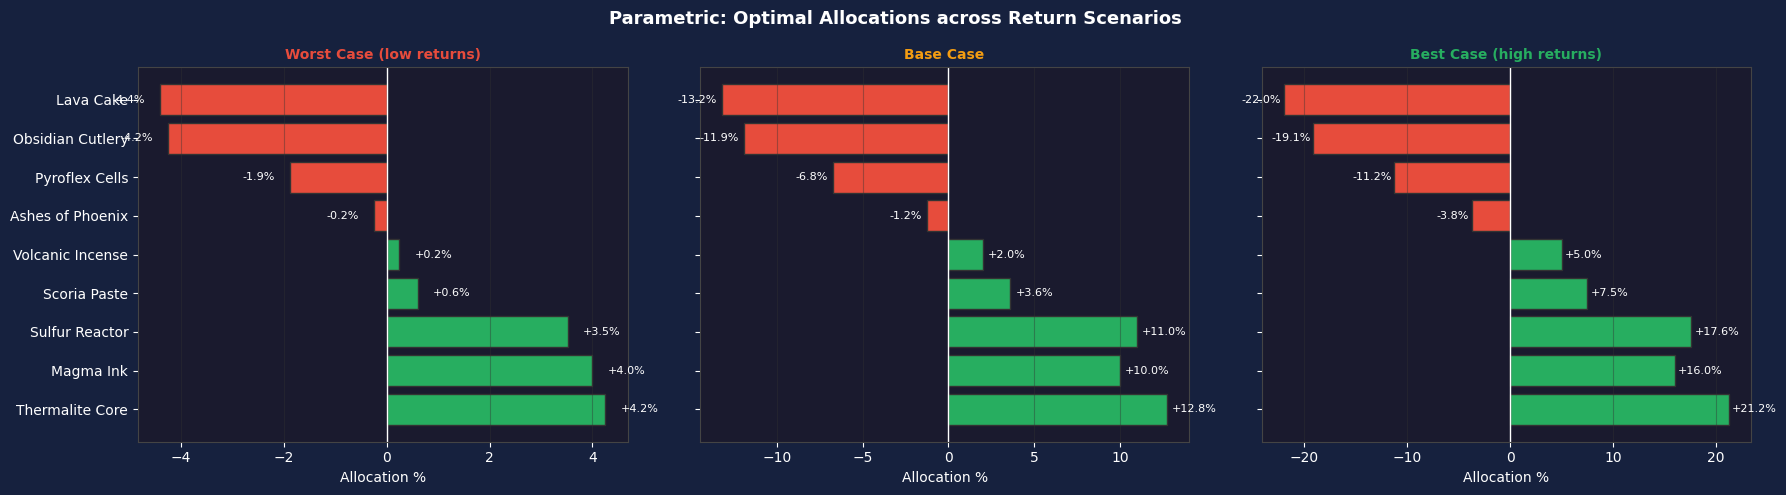


Scenario                               Gross PnL    Total Fee      Net PnL
-------------------------------------------------------------------------
Worst Case (low returns)                   1,599        8,788       -7,189
Base Case                                 10,975       76,350      -65,375
Best Case (high returns)                  33,963      208,896     -174,934


In [7]:
# ════════════════════════════════════════════════════════════════
# CELL 4 — PARAMETRIC OPTIMIZATION
# Optimize allocation as a function of return estimates.
# Sweep over (low, base, high) and show how optimal alloc changes.
# ════════════════════════════════════════════════════════════════

def optimize_allocations(ret_estimates: np.ndarray, budget_cap: float = 100.0) -> np.ndarray:
    """
    Given signed expected returns for each asset, find optimal unsigned allocations.
    Uses analytical v* = r*50 capped by budget constraint.
    ret_estimates: array of SIGNED risk-adjusted returns
    Returns: array of SIGNED allocations (positive=buy, negative=sell)
    """
    pcts_opt = np.abs(ret_estimates) * 50  # analytical per-asset optima
    pcts_opt = np.minimum(pcts_opt, 100)   # hard cap

    # Budget constraint: sum of buys ≤ budget_cap, sum of sells ≤ budget_cap
    buy_mask  = ret_estimates > 0
    sell_mask = ret_estimates < 0

    sum_buys  = pcts_opt[buy_mask].sum()
    sum_sells = pcts_opt[sell_mask].sum()

    if sum_buys > budget_cap:
        pcts_opt[buy_mask]  *= budget_cap / sum_buys
    if sum_sells > budget_cap:
        pcts_opt[sell_mask] *= budget_cap / sum_sells

    return pcts_opt * np.sign(ret_estimates)  # restore direction


# Compute allocations under low / base / high return scenarios
scenarios = {
    'Worst Case (low returns)':  LOWS  * CONFS * DIRS,
    'Base Case':                 BASES * CONFS * DIRS,
    'Best Case (high returns)':  HIGHS * CONFS * DIRS,
}

alloc_results = {}
for scenario, ret_arr in scenarios.items():
    alloc_results[scenario] = optimize_allocations(ret_arr)

# Visualize how allocations shift across scenarios
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
colors_map = {'Worst Case (low returns)': '#e74c3c', 'Base Case': '#f39c12', 'Best Case (high returns)': '#27ae60'}

for ax, (scenario, allocs) in zip(axes, alloc_results.items()):
    bar_colors = ['#27ae60' if a > 0 else '#e74c3c' for a in allocs]
    ax.barh(NAMES, allocs, color=bar_colors, edgecolor='#333')
    ax.axvline(0, color='white', lw=1)
    ax.set_title(scenario, color=colors_map[scenario], fontsize=10, fontweight='bold')
    ax.set_xlabel('Allocation %')
    ax.grid(axis='x')
    for i, v in enumerate(allocs):
        ax.text(v + (0.3 if v>=0 else -0.3), i, f'{v:+.1f}%', va='center',
                ha='left' if v>=0 else 'right', fontsize=8)

plt.suptitle('Parametric: Optimal Allocations across Return Scenarios', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Print PnL for each scenario
print(f'\n{"Scenario":<35} {"Gross PnL":>12} {"Total Fee":>12} {"Net PnL":>12}')
print('-'*73)
for scenario, allocs in alloc_results.items():
    rets_actual = np.abs(scenarios[scenario]) / CONFS  # remove confidence scaling for gross calc
    rets_signed = rets_actual * np.sign(allocs)
    gross = np.sum((allocs/100) * BUDGET * rets_actual)
    total_fee = np.sum((np.abs(allocs)/100)**2 * BUDGET)
    net = gross - total_fee
    print(f'{scenario:<35} {gross:>12,.0f} {total_fee:>12,.0f} {net:>12,.0f}')

In [8]:
# ════════════════════════════════════════════════════════════════
# CELL 5 — SCIPY NUMERICAL OPTIMIZER
# Full constrained optimization — no analytical approximations.
# Optimizes signed allocations directly.
# ════════════════════════════════════════════════════════════════

def scipy_optimize(ret_estimates: np.ndarray, budget_cap: float = 100.0,
                   method: str = 'SLSQP', verbose: bool = True) -> np.ndarray:
    """
    Full numerical optimization of signed allocations.
    ret_estimates: signed expected returns per asset
    Returns: optimal signed allocation array
    """
    def neg_pnl(pcts):
        gross = np.sum((pcts / 100) * BUDGET * ret_estimates)
        fees  = np.sum((np.abs(pcts) / 100)**2 * BUDGET)
        return -(gross - fees)

    buy_idx  = np.where(ret_estimates > 0)[0]
    sell_idx = np.where(ret_estimates < 0)[0]

    constraints = []
    if len(buy_idx):  constraints.append({'type':'ineq','fun': lambda p,b=buy_idx:  budget_cap - np.sum( p[b])})
    if len(sell_idx): constraints.append({'type':'ineq','fun': lambda p,s=sell_idx: budget_cap - np.sum(-p[s])})

    # Bounds: buys in [0,100], sells in [-100,0]
    bounds = [(0, 100) if r > 0 else (-100, 0) for r in ret_estimates]

    x0 = optimize_allocations(ret_estimates, budget_cap)  # warm-start with analytical

    result = minimize(neg_pnl, x0, method=method, bounds=bounds,
                      constraints=constraints, options={'ftol':1e-14,'maxiter':50000})

    if verbose:
        print(f'Optimization: {result.message}')
        print(f'Net PnL: {-result.fun:,.0f} XIREC')

    return result.x


print('=== SCIPY OPTIMIZATION — BASE CASE ===')
base_rets = BASES * CONFS * DIRS
scipy_allocs = scipy_optimize(base_rets)

print(f'\n{"Asset":<22} {"Direction":>10} {"Scipy Alloc%":>14} {"Analytical Alloc%":>18}')
print('-'*68)
analytical_allocs = optimize_allocations(base_rets)
for i, name in enumerate(NAMES):
    d = 'BUY' if DIRS[i] > 0 else 'SELL'
    print(f'{name:<22} {d:>10} {scipy_allocs[i]:>13.3f}% {analytical_allocs[i]:>17.3f}%')

print('\n→ Scipy and analytical should agree closely — confirms closed-form is correct.')

=== SCIPY OPTIMIZATION — BASE CASE ===
Optimization: Optimization terminated successfully
Net PnL: 76,350 XIREC

Asset                   Direction   Scipy Alloc%  Analytical Alloc%
--------------------------------------------------------------------
Thermalite Core               BUY        12.750%            12.750%
Magma Ink                     BUY        10.000%            10.000%
Sulfur Reactor                BUY        11.000%            11.000%
Scoria Paste                  BUY         3.600%             3.600%
Volcanic Incense              BUY         2.000%             2.000%
Ashes of Phoenix             SELL        -1.250%            -1.250%
Pyroflex Cells               SELL        -6.750%            -6.750%
Obsidian Cutlery             SELL       -11.900%           -11.900%
Lava Cake                    SELL       -13.200%           -13.200%

→ Scipy and analytical should agree closely — confirms closed-form is correct.


Running robust (minimax) optimization...
Done. Worst-case PnL: 39,380 XIREC


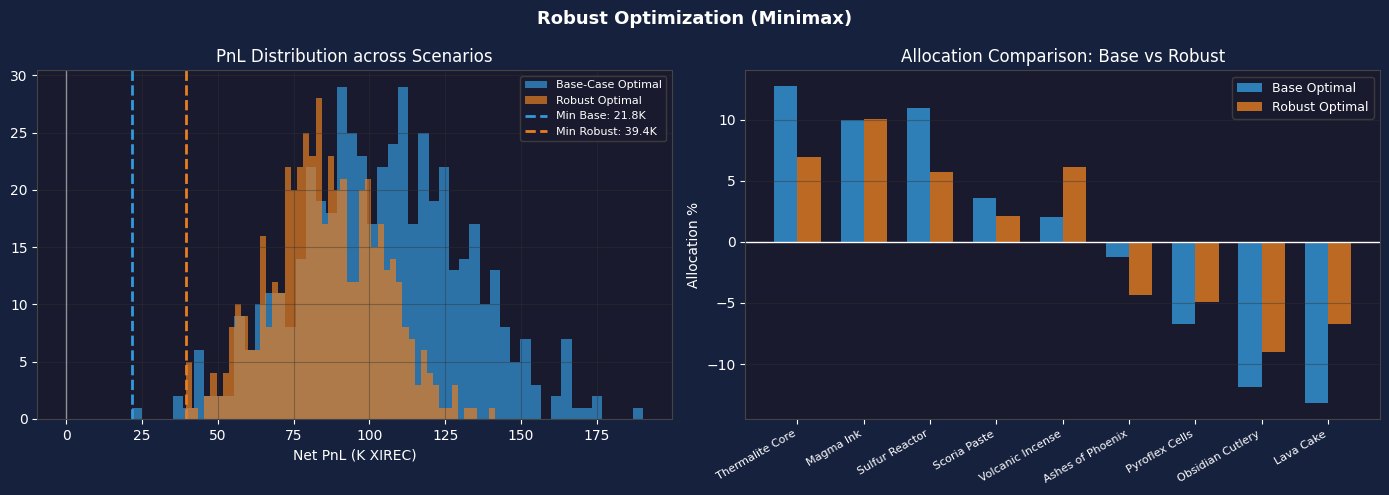


Metric                            Base Optimal  Robust Optimal
--------------------------------------------------------------
Mean PnL                               104,313          85,790
Median PnL                             104,814          85,224
Worst-case PnL                          21,780          39,380
Best-case PnL                          190,247         141,478
Std Dev PnL                             27,402          18,113
P(PnL > 0)                             100.0%         100.0%
Sharpe-like (mean/std)                       4               5


In [9]:
# ════════════════════════════════════════════════════════════════
# CELL 6 — ROBUST OPTIMIZATION
# Find allocations that maximize WORST-CASE PnL across all
# combinations of (low, base, high) return scenarios.
# This is a minimax problem: max_alloc min_scenario PnL
# ════════════════════════════════════════════════════════════════

import itertools

# Build all 3^N return scenarios (each asset can be low/base/high)
# For tractability, use a random sample if N is large
N_SAMPLES_ROBUST = 500  # number of random scenarios for robust optimization

np.random.seed(42)
robust_scenario_rets = []
for _ in range(N_SAMPLES_ROBUST):
    # For each asset, sample return uniformly from [low, high]
    r = np.random.uniform(LOWS, HIGHS) * DIRS
    robust_scenario_rets.append(r)
robust_scenario_rets = np.array(robust_scenario_rets)  # (N_SAMPLES, N_ASSETS)


def worst_case_pnl(pcts: np.ndarray, scenario_rets: np.ndarray) -> float:
    """Returns the minimum PnL across all scenarios for given allocations."""
    fees = np.sum((np.abs(pcts) / 100)**2 * BUDGET)
    gross_per_scenario = np.sum((pcts / 100) * BUDGET * scenario_rets, axis=1)
    net_per_scenario = gross_per_scenario - fees
    return net_per_scenario.min()


def neg_worst_case(pcts):
    return -worst_case_pnl(pcts, robust_scenario_rets)


buy_idx  = np.where(DIRS > 0)[0]
sell_idx = np.where(DIRS < 0)[0]

constraints_robust = [
    {'type':'ineq','fun': lambda p: 100 - np.sum( p[buy_idx])},
    {'type':'ineq','fun': lambda p: 100 - np.sum(-p[sell_idx])},
]
bounds_robust = [(0,100) if d>0 else (-100,0) for d in DIRS]
x0_robust = optimize_allocations(base_rets)

print('Running robust (minimax) optimization...')
robust_result = minimize(neg_worst_case, x0_robust, method='SLSQP',
                         bounds=bounds_robust, constraints=constraints_robust,
                         options={'ftol':1e-10,'maxiter':20000})
robust_allocs = robust_result.x
print(f'Done. Worst-case PnL: {-robust_result.fun:,.0f} XIREC')

# Compare robust vs base-case-optimal
base_allocs = scipy_optimize(base_rets, verbose=False)

# Distribution of PnL across scenarios for both strategies
fees_base   = np.sum((np.abs(base_allocs)/100)**2 * BUDGET)
fees_robust = np.sum((np.abs(robust_allocs)/100)**2 * BUDGET)

pnl_base   = np.sum((base_allocs/100)*BUDGET*robust_scenario_rets,axis=1) - fees_base
pnl_robust = np.sum((robust_allocs/100)*BUDGET*robust_scenario_rets,axis=1) - fees_robust

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pnl_base/1000,   bins=50, alpha=0.7, color='#3498db', label='Base-Case Optimal')
axes[0].hist(pnl_robust/1000, bins=50, alpha=0.7, color='#e67e22', label='Robust Optimal')
axes[0].axvline(pnl_base.min()/1000,   color='#3498db', lw=2, ls='--', label=f'Min Base: {pnl_base.min()/1000:.1f}K')
axes[0].axvline(pnl_robust.min()/1000, color='#e67e22', lw=2, ls='--', label=f'Min Robust: {pnl_robust.min()/1000:.1f}K')
axes[0].axvline(0, color='white', lw=1, alpha=0.5)
axes[0].set_xlabel('Net PnL (K XIREC)')
axes[0].set_title('PnL Distribution across Scenarios')
axes[0].legend(fontsize=8)
axes[0].grid(True)

comp_data = pd.DataFrame({
    'Base Optimal': base_allocs,
    'Robust Optimal': robust_allocs
}, index=NAMES)

x = np.arange(N)
w = 0.35
axes[1].bar(x - w/2, comp_data['Base Optimal'],   w, color='#3498db', label='Base Optimal',   alpha=0.8)
axes[1].bar(x + w/2, comp_data['Robust Optimal'], w, color='#e67e22', label='Robust Optimal', alpha=0.8)
axes[1].axhline(0, color='white', lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(NAMES, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('Allocation %')
axes[1].set_title('Allocation Comparison: Base vs Robust')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y')

plt.suptitle('Robust Optimization (Minimax)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n{"Metric":<30} {"Base Optimal":>15} {"Robust Optimal":>15}')
print('-'*62)
metrics = [
    ('Mean PnL', pnl_base.mean(), pnl_robust.mean()),
    ('Median PnL', np.median(pnl_base), np.median(pnl_robust)),
    ('Worst-case PnL', pnl_base.min(), pnl_robust.min()),
    ('Best-case PnL', pnl_base.max(), pnl_robust.max()),
    ('Std Dev PnL', pnl_base.std(), pnl_robust.std()),
    ('P(PnL > 0)', (pnl_base>0).mean(), (pnl_robust>0).mean()),
    ('Sharpe-like (mean/std)', pnl_base.mean()/pnl_base.std(), pnl_robust.mean()/pnl_robust.std()),
]
for label, b, r in metrics:
    if 'P(' in label:
        print(f'{label:<30} {b:>14.1%} {r:>14.1%}')
    else:
        print(f'{label:<30} {b:>15,.0f} {r:>15,.0f}')

Finding MC-optimal allocation...
MC-Optimal mean PnL: 50,859


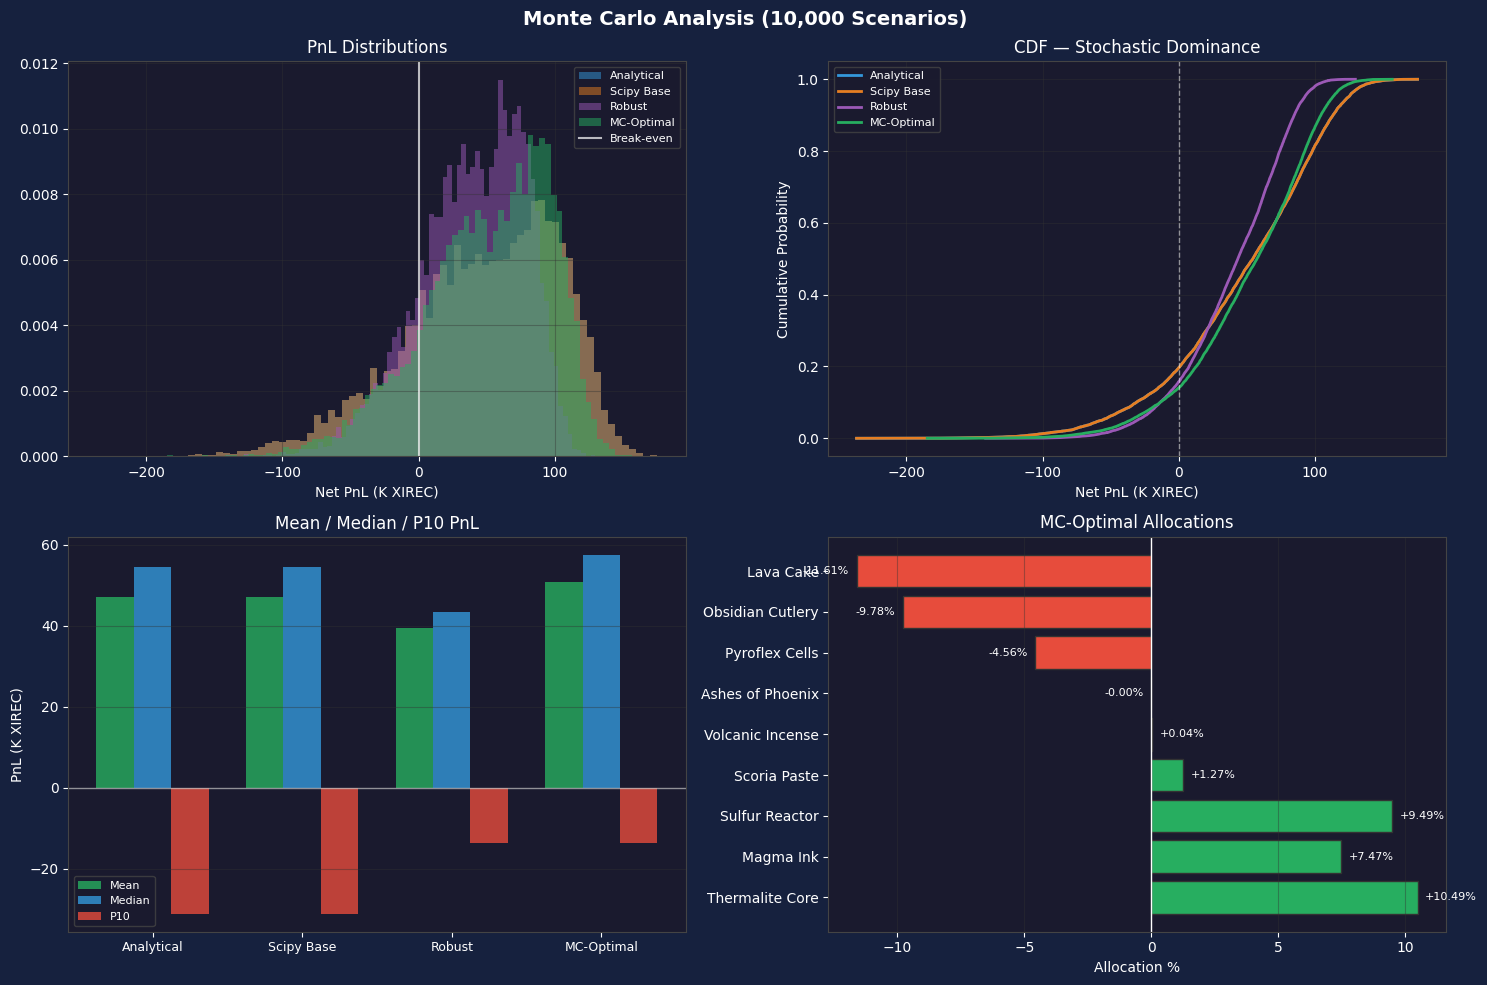


Metric                   Analytical      Scipy Base          Robust      MC-Optimal
--------------------------------------------------------------------------------
Mean                         47,198          47,198          39,377          50,859
Median                       54,514          54,514          43,450          57,544
Std                          56,397          56,397          38,221          46,415
P10                         -31,091         -31,091         -13,707         -13,520
P25                          11,674          11,674          14,409          21,229
P90                         113,406         113,406          84,902         104,471
Min                        -236,673        -236,673        -141,826        -184,756
Max                         175,513         175,513         129,819         156,911
P(profit > 0)                80.4%          80.4%          84.2%          85.9%


In [10]:
# ════════════════════════════════════════════════════════════════
# CELL 7 — MONTE CARLO SIMULATION (10,000 scenarios)
# Model returns as truncated normals within [low, high],
# mean = base, confidence affects direction-flip probability.
# ════════════════════════════════════════════════════════════════

N_MC = 10_000
np.random.seed(123)

def sample_returns_mc(n_samples: int) -> np.ndarray:
    """
    Sample signed returns for each asset.
    - Magnitude sampled from truncated normal in [low, high] with mean=base
    - Direction flips with probability (1 - confidence)
    Returns array of shape (n_samples, N_ASSETS) — signed returns
    """
    samples = np.zeros((n_samples, N))
    for i in range(N):
        low, base, high = LOWS[i], BASES[i], HIGHS[i]
        sigma = (high - low) / 4  # rough std estimate
        a, b = (low - base) / sigma, (high - base) / sigma
        magnitudes = truncnorm.rvs(a, b, loc=base, scale=sigma, size=n_samples)
        magnitudes = np.clip(magnitudes, low, high)

        # Direction: correct with prob=conf, flipped with prob=(1-conf)
        direction_flips = np.random.rand(n_samples) > CONFS[i]
        directions = np.where(direction_flips, -DIRS[i], DIRS[i])

        samples[:, i] = magnitudes * directions  # signed returns
    return samples


mc_rets = sample_returns_mc(N_MC)  # (10000, 9)

def mc_pnl(allocs: np.ndarray, rets: np.ndarray) -> np.ndarray:
    """Compute net PnL for each MC scenario. Returns array of shape (n_samples,)."""
    fees = np.sum((np.abs(allocs)/100)**2 * BUDGET)
    gross = np.sum((allocs/100) * BUDGET * rets, axis=1)
    return gross - fees


# Evaluate all three allocation strategies on MC returns
pnl_analytical = mc_pnl(analytical_allocs, mc_rets)
pnl_scipy      = mc_pnl(base_allocs, mc_rets)
pnl_robust_mc  = mc_pnl(robust_allocs, mc_rets)


# ── Find the MC-optimal allocation (maximizes expected PnL over MC) ──
def neg_expected_pnl_mc(pcts):
    return -mc_pnl(pcts, mc_rets).mean()

bounds_mc = [(0,100) if d>0 else (-100,0) for d in DIRS]
constraints_mc = [
    {'type':'ineq','fun': lambda p: 100 - np.sum( p[buy_idx])},
    {'type':'ineq','fun': lambda p: 100 - np.sum(-p[sell_idx])},
]
print('Finding MC-optimal allocation...')
mc_opt_result = minimize(neg_expected_pnl_mc, x0_robust, method='SLSQP',
                         bounds=bounds_mc, constraints=constraints_mc,
                         options={'ftol':1e-12,'maxiter':20000})
mc_opt_allocs = mc_opt_result.x
pnl_mc_opt = mc_pnl(mc_opt_allocs, mc_rets)
print(f'MC-Optimal mean PnL: {pnl_mc_opt.mean():,.0f}')


# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Monte Carlo Analysis ({N_MC:,} Scenarios)', fontsize=14, fontweight='bold')

strat_pnls = {
    'Analytical': pnl_analytical,
    'Scipy Base': pnl_scipy,
    'Robust':     pnl_robust_mc,
    'MC-Optimal': pnl_mc_opt,
}
colors_mc = ['#3498db', '#e67e22', '#9b59b6', '#27ae60']

# Subplot 1: PnL distributions
ax = axes[0, 0]
for (label, pnls), color in zip(strat_pnls.items(), colors_mc):
    ax.hist(pnls/1000, bins=80, alpha=0.5, color=color, label=label, density=True)
ax.axvline(0, color='white', lw=1.5, alpha=0.7, label='Break-even')
ax.set_xlabel('Net PnL (K XIREC)')
ax.set_title('PnL Distributions')
ax.legend(fontsize=8)
ax.grid(True)

# Subplot 2: CDF comparison
ax = axes[0, 1]
for (label, pnls), color in zip(strat_pnls.items(), colors_mc):
    sorted_p = np.sort(pnls/1000)
    cdf = np.linspace(0, 1, len(sorted_p))
    ax.plot(sorted_p, cdf, color=color, label=label, lw=2)
ax.axvline(0, color='white', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Net PnL (K XIREC)')
ax.set_ylabel('Cumulative Probability')
ax.set_title('CDF — Stochastic Dominance')
ax.legend(fontsize=8)
ax.grid(True)

# Subplot 3: Stats table as bar chart
ax = axes[1, 0]
labels_stats = list(strat_pnls.keys())
means  = [v.mean()/1000 for v in strat_pnls.values()]
p10s   = [np.percentile(v,10)/1000 for v in strat_pnls.values()]
medians= [np.median(v)/1000 for v in strat_pnls.values()]
x_s = np.arange(len(labels_stats))
ax.bar(x_s - 0.25, means,   0.25, label='Mean',   color='#27ae60', alpha=0.8)
ax.bar(x_s,        medians, 0.25, label='Median', color='#3498db', alpha=0.8)
ax.bar(x_s + 0.25, p10s,    0.25, label='P10',    color='#e74c3c', alpha=0.8)
ax.set_xticks(x_s)
ax.set_xticklabels(labels_stats, fontsize=9)
ax.set_ylabel('PnL (K XIREC)')
ax.set_title('Mean / Median / P10 PnL')
ax.legend(fontsize=8)
ax.axhline(0, color='white', lw=1, alpha=0.5)
ax.grid(axis='y')

# Subplot 4: MC-optimal allocations
ax = axes[1, 1]
bar_cols = ['#27ae60' if a>0 else '#e74c3c' for a in mc_opt_allocs]
ax.barh(NAMES, mc_opt_allocs, color=bar_cols, edgecolor='#333')
ax.axvline(0, color='white', lw=1)
ax.set_xlabel('Allocation %')
ax.set_title('MC-Optimal Allocations')
ax.grid(axis='x')
for i, v in enumerate(mc_opt_allocs):
    ax.text(v+(0.3 if v>=0 else -0.3), i, f'{v:+.2f}%', va='center',
            ha='left' if v>=0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# Print stats table
print(f'\n{"Metric":<20}', '  '.join(f'{k:>14}' for k in strat_pnls))
print('-' * 80)
for label, fn in [('Mean',np.mean),('Median',np.median),('Std',np.std),
                  ('P10',lambda x:np.percentile(x,10)),
                  ('P25',lambda x:np.percentile(x,25)),
                  ('P90',lambda x:np.percentile(x,90)),
                  ('Min',np.min),('Max',np.max)]:
    vals = [fn(v) for v in strat_pnls.values()]
    print(f'{label:<20}', '  '.join(f'{v:>14,.0f}' for v in vals))
prob_pos = [(v>0).mean() for v in strat_pnls.values()]
print(f'{"P(profit > 0)":<20}', '  '.join(f'{v:>13.1%}' for v in prob_pos))

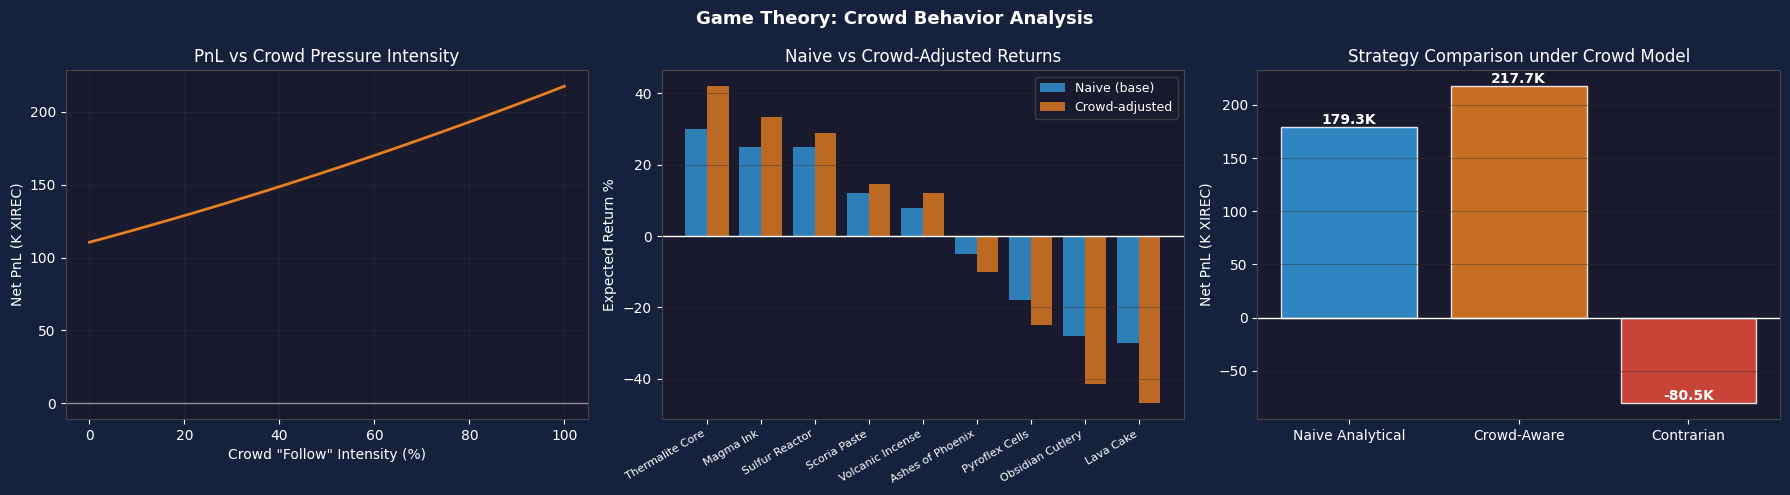


Crowd popularity scores per asset:
Asset                   Crowd Buy Pop  Naive Ret  Crowd-Adj Ret
----------------------------------------------------------------
Thermalite Core                  80%      30.0%          42.0%  (B)
Magma Ink                        78%      25.0%          33.4%  (B)
Sulfur Reactor                   65%      25.0%          28.8%  (B)
Scoria Paste                     55%      12.0%          14.7%  (B)
Volcanic Incense                 58%       8.0%          12.0%  (B)
Ashes of Phoenix                 35%      -5.0%         -10.1%  (S)
Pyroflex Cells                   20%     -18.0%         -25.0%  (S)
Obsidian Cutlery                 10%     -28.0%         -41.5%  (S)
Lava Cake                         8%     -30.0%         -46.8%  (S)


In [11]:
# ════════════════════════════════════════════════════════════════
# CELL 8 — GAME THEORY: CROWD BEHAVIOR ADJUSTMENT
#
# Key mechanic from the problem:
#  "How people submit their answers will move the actual returns
#   within the range, so if everybody thinks something is a
#   strong buy, price will go up MORE than the anchor."
#
# Model:
#   actual_return = anchor + crowd_pressure * (range / 2)
#   crowd_pressure = f(average_crowd_allocation)
#
# If everyone buys an asset heavily, the return gets pulled
# toward the HIGH end of the range (meaning less upside left).
# Contrarian insight: assets that most people overlook or
# misprice will have returns closer to the anchor.
# ════════════════════════════════════════════════════════════════

# Popularity prior: how much do we expect the crowd to buy/sell each asset?
# Scale 0-1: 1 = everyone strongly buys, 0 = everyone strongly sells
# Estimate based on how obvious the signal is
CROWD_BUY_POPULARITY = {
    #  How popular is this as a BUY with the crowd? (0=nobody, 1=everyone)
    'Thermalite Core':   0.80,  # very obvious strong-buy signal
    'Magma Ink':         0.78,  # very hyped, will be popular buy
    'Sulfur Reactor':    0.65,  # index inclusion is clear but less flashy
    'Scoria Paste':      0.55,  # influencer-driven, decent following
    'Volcanic Incense':  0.58,  # influencer says buy openly
    'Ashes of Phoenix':  0.35,  # mixed signal, some will sell
    'Pyroflex Cells':    0.20,  # clear sell story
    'Obsidian Cutlery':  0.10,  # very obvious sell
    'Lava Cake':         0.08,  # very obvious sell
}

crowd_pop = np.array([CROWD_BUY_POPULARITY[n] for n in NAMES])

def crowd_adjusted_return(crowd_buy_prob: np.ndarray) -> np.ndarray:
    """
    Model how crowd behavior shifts realized returns within [low, high].
    crowd_buy_prob in [0,1]: probability crowd buys this asset.
    If crowd buys (pop=1), actual return pushed to HIGH (all upside priced in for buys,
    but less upside for SELL positions on it).
    Returns: expected realized returns (signed) after crowd effect.
    """
    realized = np.zeros(N)
    for i in range(N):
        pop = crowd_buy_prob[i]  # 0=everyone sells, 1=everyone buys
        mid = (LOWS[i] + HIGHS[i]) / 2
        half_range = (HIGHS[i] - LOWS[i]) / 2

        if DIRS[i] == 1:  # we intend to BUY
            # If crowd also buys heavily (pop→1), return pushed HIGH = more upside
            # but competition means our OWN submission contributes less uniquely
            # Net: return shifts toward high end, but with diminishing marginal benefit
            crowd_push = (pop - 0.5) * 2  # normalized to [-1,+1]
            realized[i] = (mid + crowd_push * half_range) * DIRS[i]
        else:  # we intend to SELL
            # If crowd sells (pop→0), return drops more = our SELL profits more
            crowd_push = (0.5 - pop) * 2  # normalized: low pop (everyone sells) → +1
            realized[i] = (mid + crowd_push * half_range) * DIRS[i]
    return realized


# Scenario sweep: crowd buy popularity from 0% to 100%
crowd_sweep = np.linspace(0, 1, 50)

# For each crowd level, compute adjusted returns & optimal allocation & PnL
results_crowd = []
for crowd_scale in crowd_sweep:
    # Scale crowd popularity toward/away from base
    crowd_prob = 0.5 + crowd_scale * (crowd_pop - 0.5)  # blend toward neutral
    adj_rets = crowd_adjusted_return(crowd_prob)
    allocs_adj = optimize_allocations(adj_rets)
    pnl = portfolio_net_pnl(allocs_adj, adj_rets)
    results_crowd.append({'crowd_scale': crowd_scale, 'pnl': pnl,
                           'allocs': allocs_adj, 'rets': adj_rets})

pnls_crowd = np.array([r['pnl'] for r in results_crowd])

# Contrarian vs crowd-following PnL comparison
# Crowd-following: use same direction as majority
# Contrarian: flip positions where crowd is very lopsided

def contrarian_allocs(crowd_prob: np.ndarray, threshold: float = 0.70) -> np.ndarray:
    """Where crowd is very lopsided (>threshold buy or <1-threshold buy),
       take the OPPOSITE position since return will be pulled to the extreme already."""
    adj_rets = crowd_adjusted_return(crowd_prob)
    # For highly popular BUYs: crowd has already pushed price up, less upside
    # For highly popular SELLs: crowd has already pushed price down, less downside
    contrarian_dirs = DIRS.copy()
    for i in range(N):
        if crowd_prob[i] > threshold and DIRS[i] == 1:
            # Everyone is buying this, return already pulled HIGH — fade it
            contrarian_dirs[i] = -1  # contrarian: sell the crowded buy
        elif crowd_prob[i] < (1 - threshold) and DIRS[i] == -1:
            contrarian_dirs[i] = 1   # contrarian: buy the crowded sell
    return optimize_allocations(adj_rets * contrarian_dirs)


# Compute expected returns under crowd model with base popularity
base_crowd_rets = crowd_adjusted_return(crowd_pop)
allocs_crowd_aware = optimize_allocations(base_crowd_rets)
allocs_contrarian  = contrarian_allocs(crowd_pop, threshold=0.75)

pnl_crowd_aware  = portfolio_net_pnl(allocs_crowd_aware, base_crowd_rets)
pnl_contrarian   = portfolio_net_pnl(allocs_contrarian,  base_crowd_rets)
pnl_base_naive   = portfolio_net_pnl(analytical_allocs,  base_crowd_rets)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Game Theory: Crowd Behavior Analysis', fontsize=13, fontweight='bold')

axes[0].plot(crowd_sweep * 100, pnls_crowd/1000, color='#e67e22', lw=2)
axes[0].set_xlabel('Crowd "Follow" Intensity (%)')
axes[0].set_ylabel('Net PnL (K XIREC)')
axes[0].set_title('PnL vs Crowd Pressure Intensity')
axes[0].axhline(0, color='white', lw=1, alpha=0.5)
axes[0].grid(True)

# Crowd-adjusted returns vs naive returns
naive_rets = BASES * DIRS
x_a = np.arange(N)
axes[1].bar(x_a - 0.2, naive_rets*100,       0.4, label='Naive (base)',    color='#3498db', alpha=0.8)
axes[1].bar(x_a + 0.2, base_crowd_rets*100,  0.4, label='Crowd-adjusted',  color='#e67e22', alpha=0.8)
axes[1].set_xticks(x_a)
axes[1].set_xticklabels(NAMES, rotation=30, ha='right', fontsize=8)
axes[1].axhline(0, color='white', lw=1)
axes[1].set_ylabel('Expected Return %')
axes[1].set_title('Naive vs Crowd-Adjusted Returns')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y')

# Strategy comparison under crowd model
strats_g = ['Naive Analytical', 'Crowd-Aware', 'Contrarian']
pnls_g   = [pnl_base_naive/1000, pnl_crowd_aware/1000, pnl_contrarian/1000]
colors_g = ['#3498db', '#e67e22', '#e74c3c']
bars = axes[2].bar(strats_g, pnls_g, color=colors_g, edgecolor='white', alpha=0.85)
axes[2].set_ylabel('Net PnL (K XIREC)')
axes[2].set_title('Strategy Comparison under Crowd Model')
axes[2].axhline(0, color='white', lw=1)
axes[2].grid(axis='y')
for bar, v in zip(bars, pnls_g):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}K',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nCrowd popularity scores per asset:')
print(f'{"Asset":<22} {"Crowd Buy Pop":>14} {"Naive Ret":>10} {"Crowd-Adj Ret":>14}')
print('-'*64)
for i, name in enumerate(NAMES):
    d = '(B)' if DIRS[i]>0 else '(S)'
    print(f'{name:<22} {crowd_pop[i]:>13.0%} {naive_rets[i]*100:>9.1f}% {base_crowd_rets[i]*100:>13.1f}%  {d}')

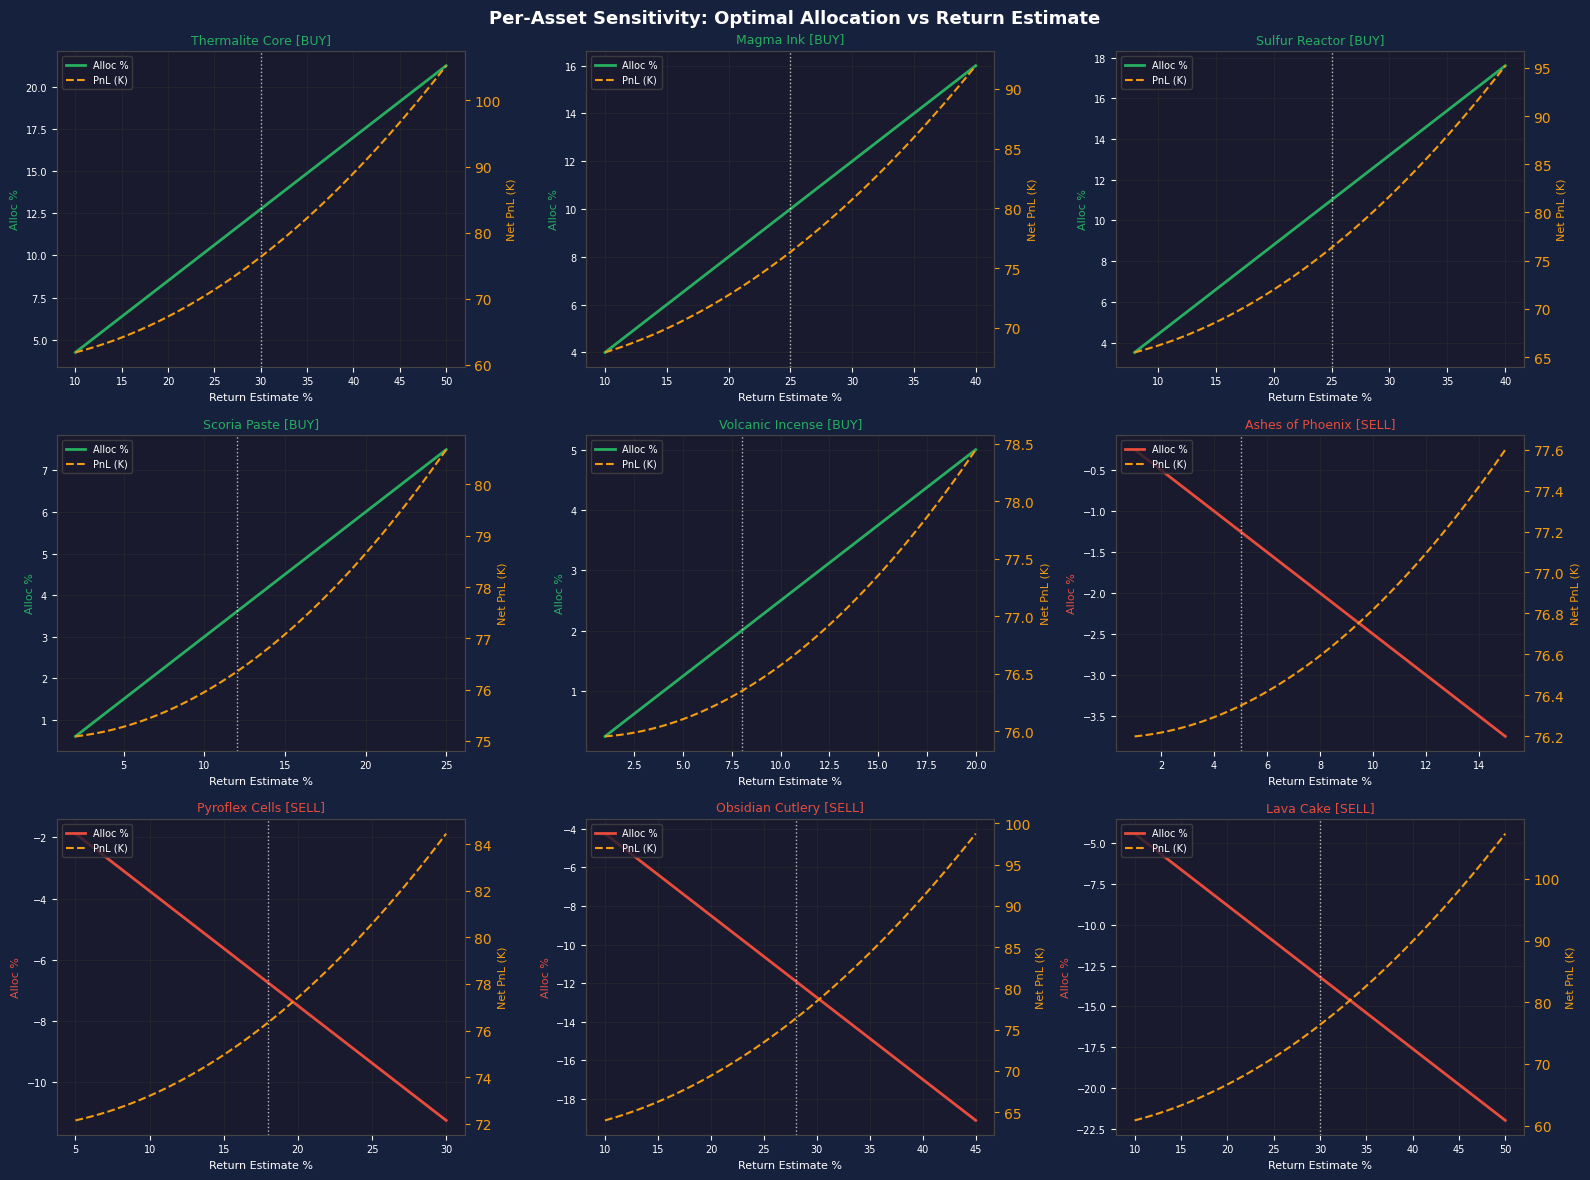

In [12]:
# ════════════════════════════════════════════════════════════════
# CELL 9 — SENSITIVITY: HOW ALLOCATION CHANGES WITH EACH RETURN
# For each asset, sweep its return estimate while holding others
# at base. Shows which assets matter most.
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Per-Asset Sensitivity: Optimal Allocation vs Return Estimate', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

base_rets_sweep = BASES * CONFS * DIRS

for idx, name in enumerate(NAMES):
    ax = axes_flat[idx]
    r_sweep = np.linspace(LOWS[idx], HIGHS[idx], 100)
    alloc_sweep = []
    pnl_sweep   = []

    for r_val in r_sweep:
        rets_tmp = base_rets_sweep.copy()
        rets_tmp[idx] = r_val * DIRS[idx] * CONFS[idx]
        allocs_tmp = optimize_allocations(rets_tmp)
        alloc_sweep.append(allocs_tmp[idx])
        pnl_sweep.append(portfolio_net_pnl(allocs_tmp, rets_tmp))

    alloc_sweep = np.array(alloc_sweep)
    pnl_sweep   = np.array(pnl_sweep)

    color = '#27ae60' if DIRS[idx] > 0 else '#e74c3c'

    ax2 = ax.twinx()
    ax.plot(r_sweep*100, alloc_sweep, color=color, lw=2, label='Alloc %')
    ax2.plot(r_sweep*100, pnl_sweep/1000, color='#f39c12', lw=1.5, ls='--', label='PnL (K)')

    # Mark base estimate
    ax.axvline(BASES[idx]*100, color='white', lw=1, ls=':', alpha=0.7)

    d_label = 'BUY' if DIRS[idx] > 0 else 'SELL'
    ax.set_title(f'{name} [{d_label}]', fontsize=9, color=color)
    ax.set_xlabel('Return Estimate %', fontsize=8)
    ax.set_ylabel('Alloc %', fontsize=8, color=color)
    ax2.set_ylabel('Net PnL (K)', fontsize=8, color='#f39c12')
    ax2.tick_params(colors='#f39c12')
    ax.tick_params(labelsize=7)
    ax.grid(True)

    # Combine legends
    lines1, labs1 = ax.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labs1+labs2, fontsize=7, loc='upper left')

plt.tight_layout()
plt.show()

In [14]:
# ════════════════════════════════════════════════════════════════
# CELL 10 — FINAL SUBMISSION BUILDER
# Blends all strategies with configurable weights.
# Prints the final portfolio ready to enter.
# ════════════════════════════════════════════════════════════════

# ── TUNE THESE WEIGHTS to choose your strategy blend ──
W_ANALYTICAL  = 0.30   # weight for pure analytical (v* = r*50)
W_MC_OPTIMAL  = 0.35   # weight for MC-optimal allocation
W_ROBUST      = 0.20   # weight for robust (minimax) allocation
W_CROWD_AWARE = 0.15   # weight for crowd-adjusted allocation
# Total must sum to 1.0
assert abs(W_ANALYTICAL + W_MC_OPTIMAL + W_ROBUST + W_CROWD_AWARE - 1.0) < 1e-6

# ── Blend allocations ──
blended = (
    W_ANALYTICAL  * analytical_allocs +
    W_MC_OPTIMAL  * mc_opt_allocs     +
    W_ROBUST      * robust_allocs     +
    W_CROWD_AWARE * allocs_crowd_aware
)

# Re-normalize to respect budget constraints
def normalize_allocs(allocs, cap=100.0):
    a = allocs.copy()
    buy_s  = np.sum(a[a > 0])
    sell_s = np.sum(np.abs(a[a < 0]))
    if buy_s  > cap: a[a > 0] *= cap / buy_s
    if sell_s > cap: a[a < 0] *= cap / sell_s
    return a

final_allocs = normalize_allocs(blended)

# Round to 2 decimal places for submission
final_allocs_rounded = np.round(final_allocs, 2)

# Verify constraints after rounding
total_buy_final  = np.sum(final_allocs_rounded[final_allocs_rounded > 0])
total_sell_final = np.sum(np.abs(final_allocs_rounded[final_allocs_rounded < 0]))

print('═'*65)
print('FINAL BLENDED PORTFOLIO')
print(f'Strategy weights: Analytical={W_ANALYTICAL:.0%}, MC={W_MC_OPTIMAL:.0%},',
      f'Robust={W_ROBUST:.0%}, Crowd={W_CROWD_AWARE:.0%}')
print('═'*65)
print()
print(f'{"Asset":<22} {"Side":<5} {"Alloc %":>9} {"Investment":>13} {"Fee":>12}')
print('-'*65)
for i, name in enumerate(NAMES):
    pct = final_allocs_rounded[i]
    if abs(pct) < 0.01:
        continue
    side = 'BUY' if pct > 0 else 'SELL'
    invested = abs(pct)/100 * BUDGET
    f = fee(abs(pct))
    print(f'{name:<22} {side:<5} {abs(pct):>8.2f}% {invested:>13,.0f} {f:>12,.0f}')

print('-'*65)
print(f'{"TOTAL BUY":>28}: {total_buy_final:>8.2f}%')
print(f'{"TOTAL SELL":>28}: {total_sell_final:>8.2f}%')
total_fee_final = np.sum((np.abs(final_allocs_rounded)/100)**2 * BUDGET)
print(f'{"TOTAL FEES":>28}: {total_fee_final:>12,.0f} XIREC')

# Expected PnL under base-case and MC
base_pnl_final = portfolio_net_pnl(final_allocs_rounded, base_rets)
mc_pnl_final   = mc_pnl(final_allocs_rounded, mc_rets)
print()
print(f'Expected PnL (base case):     {base_pnl_final:>12,.0f} XIREC')
print(f'Expected PnL (MC mean):       {mc_pnl_final.mean():>12,.0f} XIREC')
print(f'Expected PnL (MC median):     {np.median(mc_pnl_final):>12,.0f} XIREC')
print(f'Worst-case PnL (MC P5):       {np.percentile(mc_pnl_final,5):>12,.0f} XIREC')
print(f'P(profit > 0):                {(mc_pnl_final>0).mean():>12.1%}')
print()
print('📋 COPY TO SUBMISSION INTERFACE:')
print('─'*40)
for i, name in enumerate(NAMES):
    pct = final_allocs_rounded[i]
    if abs(pct) < 0.01: continue
    side = 'BUY' if pct > 0 else 'SELL'
    print(f'  {name:<22}  {side}   {abs(pct):.2f}%')

═════════════════════════════════════════════════════════════════
FINAL BLENDED PORTFOLIO
Strategy weights: Analytical=30%, MC=35%, Robust=20%, Crowd=15%
═════════════════════════════════════════════════════════════════

Asset                  Side    Alloc %    Investment          Fee
-----------------------------------------------------------------
Thermalite Core        BUY      12.03%       120,300       14,472
Magma Ink              BUY      10.14%       101,400       10,282
Sulfur Reactor         BUY       9.92%        99,200        9,841
Scoria Paste           BUY       3.04%        30,400          924
Volcanic Incense       BUY       2.73%        27,300          745
Ashes of Phoenix       SELL      2.00%        20,000          400
Pyroflex Cells         SELL      6.48%        64,800        4,199
Obsidian Cutlery       SELL     11.91%       119,100       14,185
Lava Cake              SELL     12.88%       128,800       16,589
-----------------------------------------------------

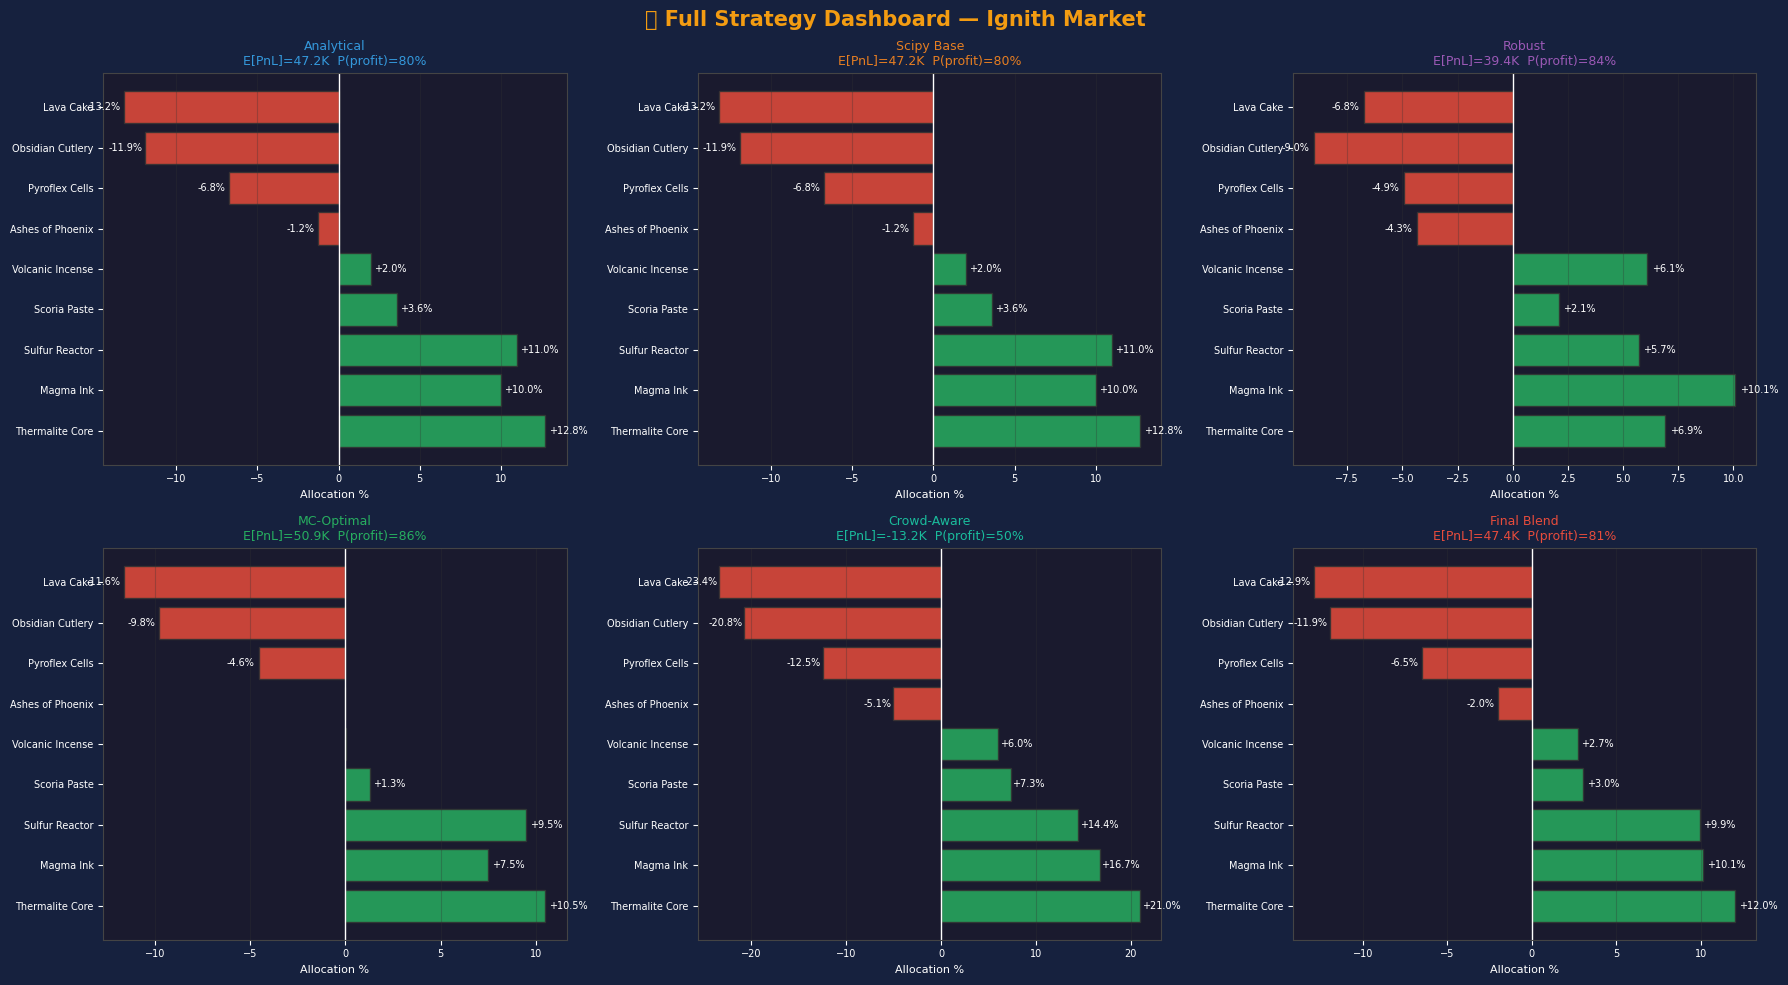


Strategy             E[PnL]      Median         P10         P90       P(>0)      Sharpe
──────────────────────────────────────────────────────────────────────────────────
Analytical            47.2K      54.5K     -31.1K     113.4K     80.4%     0.837
Scipy Base            47.2K      54.5K     -31.1K     113.4K     80.4%     0.837
Robust                39.4K      43.5K     -13.7K      84.9K     84.2%     1.030
MC-Optimal            50.9K      57.5K     -13.5K     104.5K     85.9%     1.096
Crowd-Aware          -13.2K       0.2K    -142.5K      98.0K     50.1%    -0.139
Final Blend           47.4K      54.2K     -28.0K     111.8K     81.2%     0.869


In [15]:
# ════════════════════════════════════════════════════════════════
# CELL 11 — FULL SUMMARY DASHBOARD
# ════════════════════════════════════════════════════════════════

all_strats = {
    'Analytical':    analytical_allocs,
    'Scipy Base':    base_allocs,
    'Robust':        robust_allocs,
    'MC-Optimal':    mc_opt_allocs,
    'Crowd-Aware':   allocs_crowd_aware,
    'Final Blend':   final_allocs_rounded,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('🌋 Full Strategy Dashboard — Ignith Market', fontsize=15, fontweight='bold', color='#f39c12')

palette = ['#3498db','#e67e22','#9b59b6','#27ae60','#1abc9c','#e74c3c']

for ax, (strat, allocs), color in zip(axes.flatten(), all_strats.items(), palette):
    bar_colors = ['#27ae60' if a>0 else '#e74c3c' for a in allocs]
    bars = ax.barh(NAMES, allocs, color=bar_colors, edgecolor='#333', alpha=0.85)
    ax.axvline(0, color='white', lw=1)

    pnl_s  = mc_pnl(allocs, mc_rets)
    mean_p = pnl_s.mean()
    prob_p = (pnl_s > 0).mean()

    ax.set_title(f'{strat}\nE[PnL]={mean_p/1000:.1f}K  P(profit)={prob_p:.0%}',
                 fontsize=9, color=color)
    ax.set_xlabel('Allocation %', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(axis='x', alpha=0.3)

    for bar, v in zip(bars, allocs):
        if abs(v) < 0.5: continue
        ax.text(v+(0.2 if v>=0 else -0.2), bar.get_y()+bar.get_height()/2,
                f'{v:+.1f}%', va='center', ha='left' if v>=0 else 'right',
                fontsize=7, color='white')

plt.tight_layout()
plt.show()

# Summary stats table
print(f'\n{"Strategy":<16}', '  '.join(f'{k:>10}' for k in
      ['E[PnL]','Median','P10','P90','P(>0)','Sharpe']))
print('─'*82)
for strat, allocs in all_strats.items():
    pnl_s = mc_pnl(allocs, mc_rets)
    sharpe = pnl_s.mean() / (pnl_s.std() + 1)
    print(f'{strat:<16}',
          f'{pnl_s.mean()/1000:>9.1f}K',
          f'{np.median(pnl_s)/1000:>9.1f}K',
          f'{np.percentile(pnl_s,10)/1000:>9.1f}K',
          f'{np.percentile(pnl_s,90)/1000:>9.1f}K',
          f'{(pnl_s>0).mean():>9.1%}',
          f'{sharpe:>9.3f}')